# BRFSS 2023 Cleaning

## Purpose
This notebook cleans selected BRFSS 2023 variables for later analysis. It focuses on checking the dataset, selecting useful columns, fixing data types, handling missing values, and saving a cleaned file.

In [ ]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load data
BRFSS2023_df = pd.read_csv(r"C:\Users\alin2\Downloads\BRFSS2023.csv")
BRFSS2023_df.head()

,_state,fmonth,idate,imonth,iday,iyear,dispcode,seqno,_psu,ctelenm1,...,drocdy4_,_rfbing6,_drnkwk2,_rfdrhv8,_flshot7,_pneumo3,_aidtst4,_rfseat2,_rfseat3,_drnkdrv
0,1,1,3012023,3,1,2023,1100,2023000001,2023000001,1.0,...,0,1,0,1,2.0,2.0,2.0,1,1,9
1,1,1,1062023,1,6,2023,1100,2023000002,2023000002,1.0,...,0,1,0,1,1.0,1.0,2.0,1,1,9
2,1,1,3082023,3,8,2023,1100,2023000003,2023000003,1.0,...,0,1,0,1,1.0,1.0,2.0,1,1,9
3,1,1,3062023,3,6,2023,1100,2023000004,2023000004,1.0,...,0,1,0,1,1.0,1.0,1.0,1,1,9
4,1,1,1062023,1,6,2023,1100,2023000005,2023000005,1.0,...,7,1,47,1,2.0,1.0,2.0,1,1,2


In [6]:
# Check Shape
BRFSS2023_df.shape

(433323, 350)

In [8]:
# Check Columns
BRFSS2023_df.columns.tolist()[:20]

['_state',
 'fmonth',
 'idate',
 'imonth',
 'iday',
 'iyear',
 'dispcode',
 'seqno',
 '_psu',
 'ctelenm1',
 'pvtresd1',
 'colghous',
 'statere1',
 'celphon1',
 'ladult1',
 'numadult',
 'respslc1',
 'landsex2',
 'lndsxbrt',
 'safetime']

In [10]:
# Select Variables

BRFSS2023_clean = BRFSS2023_df[['_state', '_drnkdrv', '_pneumo3']].copy()
BRFSS2023_clean.head()

,_state,_drnkdrv,_pneumo3
0,1,9,2.0
1,1,9,1.0
2,1,9,1.0
3,1,9,1.0
4,1,2,1.0


In [11]:
# Check Data Types

BRFSS2023_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 433323 entries, 0 to 433322
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _state    433323 non-null  int64  
 1   _drnkdrv  433323 non-null  int64  
 2   _pneumo3  170823 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 9.9 MB


In [12]:
# Convert to Numeric

BRFSS2023_clean['_state'] = pd.to_numeric(BRFSS2023_clean['_state'], errors='coerce')
BRFSS2023_clean['_drnkdrv'] = pd.to_numeric(BRFSS2023_clean['_drnkdrv'], errors='coerce')
BRFSS2023_clean['_pneumo3'] = pd.to_numeric(BRFSS2023_clean['_pneumo3'], errors='coerce')

In [13]:
# Function 1 — Clean Codes
def clean_codes(series, bad_codes):
    return series.replace(bad_codes, np.nan)

In [14]:
# Apply Cleaning

BRFSS2023_clean['_drnkdrv'] = clean_codes(BRFSS2023_clean['_drnkdrv'], [7, 9, 77, 99])
BRFSS2023_clean['_pneumo3'] = clean_codes(BRFSS2023_clean['_pneumo3'], [7, 9])

In [15]:
# Function 2 — Missing Percent

def missing_pct(df):
    return df.isna().mean() * 100

In [16]:
#Check Missing
missing = missing_pct(BRFSS2023_clean)
missing

_state       0.000000
_drnkdrv    51.137373
_pneumo3    65.645488
dtype: float64

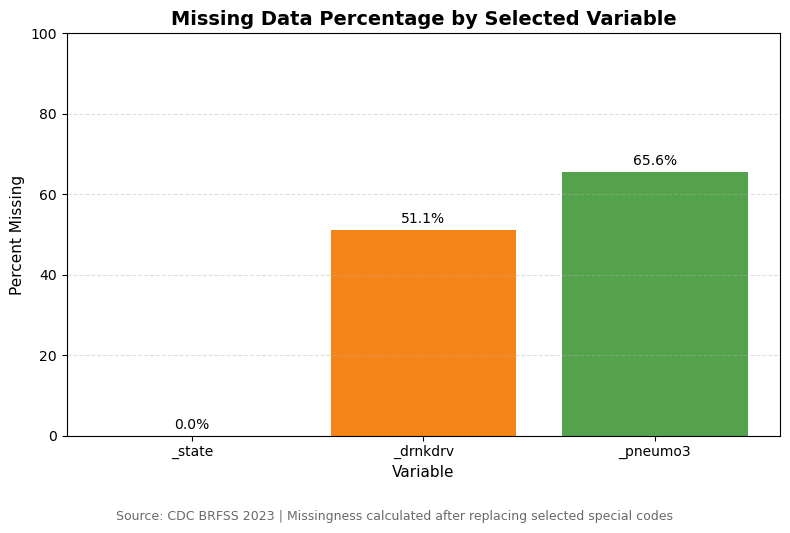

In [18]:
#Missing Chart
plt.figure(figsize=(8,5))

bars = plt.bar(
    missing.index,
    missing.values,
    color=['#4C78A8', '#F58518', '#54A24B']
)

plt.title("Missing Data Percentage by Selected Variable", fontsize=14, weight='bold')
plt.xlabel("Variable", fontsize=11)
plt.ylabel("Percent Missing", fontsize=11)
plt.ylim(0, 100)

plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.figtext(
    0.5, -0.05,
    "Source: CDC BRFSS 2023 | Missingness calculated after replacing selected special codes",
    ha='center',
    fontsize=9,
    color='dimgray'
)

plt.tight_layout()
plt.show()

### Interpretation

This chart shows that missing data is not evenly distributed across the selected BRFSS variables.

The `_state` variable has no missing values, which is expected because geographic information is typically required for each respondent. This makes it a reliable variable for grouping and comparison.

The `_drnkdrv` variable has a moderate level of missing data (about 51%). This suggests that a significant portion of respondents either did not answer or had invalid responses, which may affect how representative the results are for this behavior.

The `_pneumo3` variable has the highest missingness (about 66%), meaning more than half of the responses are unavailable. This is important because it limits the strength of any conclusions related to pneumococcal vaccination and highlights a potential issue in data collection or response patterns.

Overall, this analysis shows that data quality varies across variables, and variables with higher missingness should be interpreted more cautiously in later analysis.

In [19]:
#Check Duplicates

print(BRFSS2023_clean.duplicated().sum())

432858


In [20]:
#Remove Duplicates
BRFSS2023_clean = BRFSS2023_clean.drop_duplicates()
print(BRFSS2023_clean.shape)

(465, 3)


In [21]:
# Function 3 — Add Labels
def add_labels(series, label_dict):
    return series.map(label_dict).fillna("Missing")

In [22]:
#Apply Labels
BRFSS2023_clean['pneumo_label'] = add_labels(BRFSS2023_clean['_pneumo3'], {1.0: 'Yes', 2.0: 'No'})
BRFSS2023_clean['drnkdrv_label'] = add_labels(BRFSS2023_clean['_drnkdrv'], {1.0: 'Category 1', 2.0: 'Category 2'})

In [25]:
#Save Cleaned File

BRFSS2023_clean.to_csv(
    r"C:\Users\alin2\OneDrive\Documents\Behavioral Risk & Health Outcomes Analysis (BRFSS 2023)\data\brfss_cleaned.csv",
    index=False
)

print("File saved.")

File saved.


## Conclusion

In this notebook, the BRFSS 2023 dataset was cleaned and prepared for further analysis. A small set of relevant variables was selected, data types were corrected, and special coded values were replaced with missing values to improve data quality.

The analysis also showed that missing data is not evenly distributed across variables. In particular, the pneumococcal vaccination variable has a high level of missingness, which means it should be interpreted with caution in later analysis.

Overall, this step ensures that the dataset is more reliable and ready for the next stages of the project, including exploratory analysis, integration with CDC PLACES data, and database design.